# Hoop Explorer EDA — Transfer Portal Analytics

Exploratory notebook for the **Hoop Explorer** CSV exports in `data/hoop_explorer/`. Our capstone goal is a **transfer portal analytics platform** for college basketball teams and players.

Hoop Explorer is especially valuable for portal work because it pre-computes **RAPM** (impact independent of teammates/opponents), **on/off-style ratings**, **lineup context**, and **play-style labels** — metrics that help separate *"good stats on a weak team"* from *"genuine contributor who will translate."*

**Local files (this notebook):**
| File | Description |
|---|---|
| `all_player_stats_high_tier.csv` | Player-season stats for high-major / strong teams (672 rows, 2025–26) |
| `all_team_explorer_stats_power_6.csv` | Team-season stats for Power 6 conferences (365 rows, 2025–26) |

**References:**
- Field glossary: `notebooks/eda/justin/Hoop Explorer.md`
- Hoop Explorer site: https://hoop-explorer.com/
- Hoop Explorer Blog Docs (no API): https://hoop-explorer.blogspot.com/p/blog-page.html

**Environment:** uv (`pandas`, `numpy`, `matplotlib`, `seaborn`)

---
## 0. Setup

In [25]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

def find_project_root() -> Path:
    """Walk up from cwd until we find pyproject.toml (works regardless of kernel cwd)."""
    for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (path / 'pyproject.toml').exists():
            return path
    raise FileNotFoundError('Could not find project root (pyproject.toml). Open the repo root or notebooks folder in Jupyter.')

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data' / 'hoop_explorer'
PLAYER_PATH = DATA_DIR / 'all_player_stats_high_tier.csv'
TEAM_PATH = DATA_DIR / 'all_team_explorer_stats_power_6.csv'

for label, path in [('player', PLAYER_PATH), ('team', TEAM_PATH)]:
    if not path.exists():
        raise FileNotFoundError(f'Missing {label} file: {path}')

print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('project root:', PROJECT_ROOT)
print('data dir:', DATA_DIR)

pandas: 3.0.3
numpy: 2.4.6
project root: C:\Users\nhanj\Desktop\MIDS\Summer 2026\W210\MIDS210-Capstone
data dir: C:\Users\nhanj\Desktop\MIDS\Summer 2026\W210\MIDS210-Capstone\data\hoop_explorer


---
## 1. Basketball & Hoop Explorer Primer (for beginners)

Before diving into the numbers, here is a short glossary tied to columns you will see in these files.

### Season & structure
- **Year `2025/26`** — the NCAA season that *starts* in 2025 (fall 2025 through spring 2026).
- **Conference (`conf`)** — league grouping (ACC, Big Ten, etc.). Power 6 = ACC, Big 12, Big East, Big Ten, SEC, plus related high-major teams in this export.
- **Possession** — one team offensive trip ending in a shot, turnover, or foul sequence. Most advanced stats are *per 100 possessions*, not per game, so pace differences do not distort comparisons.

### Roles & metadata
- **`posClass`** — Hoop Explorer positional role (finer than G/F/C): e.g. `PG`, `CG` (combo guard), `WG` (wing guard), `WF` (wing forward), `S-PF` (stretch four), `PF/C`, `C`.
- **`roster.year_class`** — `Fr`, `So`, `Jr`, `Sr` (eligibility year).
- **`off_team_poss_pct`** — share of team offensive possessions the player was on the floor (0.50 = ~50% of team minutes). **Critical for portal work:** low-minute gaudy box scores are less trustworthy.
- **`transfer_src` / `transfer_dest`** — where a player transferred from / to. Empty if not a transfer; `NBA` if declared for the draft.

### Four Factors (Dean Oliver)
Team success is often summarized by four components on each end:
| Factor | Column | Plain English |
|---|---|---|
| Shooting | `off_efg` / `def_efg` | Effective FG% — rewards 3s (a made 3 counts as 1.5 made 2s). Higher offense = better. Lower defense allowed = better. |
| Turnovers | `off_to` / `def_to` | Turnover rate — % of possessions ending in a turnover. Lower offense = better; *forcing* turnovers on defense = higher `def_to` is good. |
| Free throws | `off_ftr` / `def_ftr` | Free-throw rate — how often a team gets to the line relative to field-goal attempts. |
| Rebounding | `off_orb` / `def_orb` | Offensive rebound % / defensive rebound % — second-chance opportunities vs. ending opponent possessions. |

### Impact metrics (Hoop Explorer's core value)
- **`off_rtg` / `def_rtg`** — points scored (offense) or allowed (defense) per 100 possessions *while the player is on the floor*. `def_rtg` lower is better.
- **`off_adj_rtg` / `def_adj_rtg`** — Same idea but **adjusted for opponent strength** (`off_adj_opp`, `def_adj_opp` weight competition).
- **`adj_rtg_margin`** — `(off_adj_rtg - def_adj_rtg)`. **0 ≈ average D1 player** in this scale. Positive = good two-way contributor.
- **`adj_rapm_margin`** — **RAPM** (Regularized Adjusted Plus-Minus): estimates how many points per 100 possessions the team improves with this player on court, after controlling for teammates and opponents. **The key portal metric** for "will production translate?"
- **`_prod` suffix** — Stat multiplied by possession % — credits production weighted by playing time.
- **`_pred` fields** — Model projections for how a transfer might perform at a NCAA-tournament-caliber high major next season (balanced scenario).

### Shot profile & play style
- **`off_usage`** — % of team possessions used by the player while on floor (shot, turnover, or foul drawn). ~0.20 average; 0.25+ primary scorer; 0.30+ heliocentric.
- **`off_threepr`, `off_twoprimr`, `off_twopmidr`** — shot mix: 3s, rim 2s, mid-range 2s (all as fractions 0–1).
- **`off_style_*`** — play-type frequency (`_pct`), efficiency (`_ppp` = points per play), and usage (`_usg`). Examples: Rim Attack, Pick & Roll, Post-Up, Transition.

### Percentiles & ranks in this export
- **`rank_*`** — D1 rank within tier (lower = better for most stats).
- **`pctile_*`** — Percentile 0–1 (higher = better for most offensive stats; for `def_rtg`, lower raw value is better but percentile is oriented so higher = better defender).

---
## 2. Load Data

In [26]:
players = pd.read_csv(PLAYER_PATH)
teams = pd.read_csv(TEAM_PATH)

print('Players:', players.shape)
print('Teams:  ', teams.shape)
players.head(3)

Players: (672, 317)
Teams:   (365, 441)


,conf,team,year,player_name,player_code,posClass,roster.ncaa_id,roster.number,roster.height,roster.year_class,roster.pos,roster.origin,tier,transfer_src,transfer_dest,off_adj_opp,def_adj_opp,off_poss,off_team_poss_pct,def_poss,def_team_poss_pct,off_efg,off_to,off_ftr,adj_rtg_margin,adj_prod_margin,adj_rapm_margin,adj_rapm_prod_margin,off_rtg,off_adj_rtg,...,pctile_off_style_big_cut_roll_usg,pctile_off_style_big_cut_roll_ppp,pctile_off_style_post_up_pct,pctile_off_style_post_up_usg,pctile_off_style_post_up_ppp,pctile_off_style_post_kick_pct,pctile_off_style_post_kick_usg,pctile_off_style_post_kick_ppp,pctile_off_style_pick_pop_pct,pctile_off_style_pick_pop_usg,pctile_off_style_pick_pop_ppp,pctile_off_style_high_low_pct,pctile_off_style_high_low_usg,pctile_off_style_high_low_ppp,pctile_off_style_reb_scramble_pct,pctile_off_style_reb_scramble_usg,pctile_off_style_reb_scramble_ppp,pctile_off_style_transition_pct,pctile_off_style_transition_usg,pctile_off_style_transition_ppp,posConfidences[_PG_],posConfidences[_SG_],posConfidences[_SF_],posConfidences[_PF_],posConfidences[_C_],posFreqs[_PG_],posFreqs[_SG_],posFreqs[_SF_],posFreqs[_PF_],posFreqs[_C_]
0,Atlantic Coast Conference,Duke,2025/26,"Boozer, Cameron",CmBoozer,S-PF,5041935.000,12.000,6-09,Fr,F,"Miami, FL",NaN,Duke,NBA,116.943,102.566,2096,0.837,2093,0.829,0.607,0.147,0.536,15.487,12.938,15.495,12.940,135.051,11.763,...,0.341,0.868,0.546,0.867,0.931,0.516,0.862,0.637,0.202,0.482,0.959,0.067,0.350,0.933,0.675,0.947,0.841,0.124,0.498,0.803,0.002,0.031,0.410,0.556,0.001,0.000,0.000,0.000,0.455,0.545
1,Big Ten Conference,Michigan,2025/26,"Lendeborg, Yaxel",YaLendeborg,S-PF,5175737.000,23.000,6-09,Sr,F,"Pennsauken, NJ",NaN,NaN,NaN,120.002,101.555,2107,0.750,2082,0.740,0.603,0.096,0.426,13.230,9.877,14.932,11.142,142.101,9.059,...,0.053,0.997,0.367,0.445,0.977,0.474,0.619,0.945,0.513,0.580,0.850,0.350,0.450,1.000,0.622,0.724,0.872,0.869,0.885,0.815,0.010,0.174,0.402,0.412,0.001,0.000,0.000,0.305,0.652,0.043
2,Big Ten Conference,Illinois,2025/26,"Wagler, Keaton",KeWagler,CG,5254165.000,23.000,6-06,Fr,G,"Lenexa, KS",NaN,Illinois,NBA,117.930,102.608,2017,0.834,1994,0.828,0.541,0.126,0.476,11.543,9.618,12.398,10.326,135.379,9.726,...,0.003,0.003,0.002,0.002,0.635,0.003,0.003,0.003,0.005,0.005,0.010,0.017,0.017,0.017,0.050,0.144,0.397,0.031,0.194,0.367,0.346,0.519,0.114,0.021,0.000,0.399,0.591,0.010,0.000,0.000


In [27]:
def parse_height_to_inches(height: str) -> float:
    """Convert Hoop Explorer height like '6-09' to total inches."""
    if pd.isna(height) or not isinstance(height, str) or '-' not in height:
        return np.nan
    ft, inches = height.split('-', 1)
    return int(ft) * 12 + int(inches)


def clean_transfer_col(series: pd.Series) -> pd.Series:
    return series.fillna('').astype(str).str.strip()


players = players.copy()
players['height_in'] = players['roster.height'].map(parse_height_to_inches)
players['transfer_src'] = clean_transfer_col(players['transfer_src'])
players['transfer_dest'] = clean_transfer_col(players['transfer_dest'])
players['is_transfer_out'] = players['transfer_dest'].ne('')
players['is_nba_declare'] = players['transfer_dest'].eq('NBA')
players['minutes_proxy'] = players['off_team_poss_pct']  # fraction of team offensive possessions

# Play-style columns (offense only for players)
STYLE_BASES = [
    'rim_attack', 'attack_kick', 'perimeter_sniper', 'dribble_jumper', 'mid_range',
    'hits_cutter', 'perimeter_cut', 'pnr_passer', 'big_cut_roll', 'post_up',
    'post_kick', 'pick_pop', 'high_low', 'reb_scramble', 'transition',
]
STYLE_LABELS = {
    'rim_attack': 'Rim Attack',
    'attack_kick': 'Attack & Kick',
    'perimeter_sniper': 'Perimeter Sniper',
    'dribble_jumper': 'Dribble Jumper',
    'mid_range': 'Mid-Range',
    'hits_cutter': 'Hits Cutter',
    'perimeter_cut': 'Perimeter Cut',
    'pnr_passer': 'PnR Passer',
    'big_cut_roll': 'Big Cut & Roll',
    'post_up': 'Post-Up',
    'post_kick': 'Inside Out',
    'pick_pop': 'Pick & Pop',
    'high_low': 'High-Low',
    'reb_scramble': 'Scramble',
    'transition': 'Transition',
}

teams = teams.copy()
teams['record'] = teams['wins'].astype(str) + '-' + teams['losses'].astype(str)

players[['player_name', 'team', 'posClass', 'roster.year_class', 'roster.height', 'height_in',
         'off_team_poss_pct', 'adj_rtg_margin', 'adj_rapm_margin', 'transfer_dest']].head(8)

,player_name,team,posClass,roster.year_class,roster.height,height_in,off_team_poss_pct,adj_rtg_margin,adj_rapm_margin,transfer_dest
0,"Boozer, Cameron",Duke,S-PF,Fr,6-09,81.000,0.837,15.487,15.495,NBA
1,"Lendeborg, Yaxel",Michigan,S-PF,Sr,6-09,81.000,0.750,13.230,14.932,
2,"Wagler, Keaton",Illinois,CG,Fr,6-06,78.000,0.834,11.543,12.398,NBA
3,"Fears Jr., Jeremy",Michigan St.,PG,Jr,6-02,74.000,0.817,11.466,11.685,NBA
4,"Thornton, Bruce",Ohio St.,CG,Sr,6-02,74.000,0.904,11.622,11.228,
5,"Veesaar, Henri",North Carolina,PF/C,Jr,7-00,84.000,0.738,8.767,11.194,NBA
6,"Momcilovic, Milan",Iowa St.,WF,Jr,6-08,80.000,0.752,11.573,11.106,NBA
7,"Dybantsa, AJ",BYU,WF,Fr,6-09,81.000,0.865,11.784,11.095,NBA


---
## 3. Dataset Overview & Data Quality

In [28]:
overview = pd.DataFrame({
    'dataset': ['players', 'teams'],
    'rows': [len(players), len(teams)],
    'columns': [players.shape[1], teams.shape[1]],
    'seasons': [players['year'].nunique(), teams['year'].nunique()],
    'unique_teams': [players['team'].nunique(), teams['team_name'].nunique()],
})
overview

,dataset,rows,columns,seasons,unique_teams
0,players,672,321,1,83
1,teams,365,442,1,365


In [29]:
print('Player conferences:', sorted(players['conf'].unique()))
print()
print('Positional roles (posClass):')
display(players['posClass'].value_counts().to_frame('count'))
print()
print('Class year breakdown:')
display(players['roster.year_class'].value_counts().to_frame('count'))
print()
print('Transfer signals in player export:')
print('  transfer_dest filled:', players['is_transfer_out'].sum())
print('  NBA declarations:    ', players['is_nba_declare'].sum())
print('  transfer_src filled: ', (players['transfer_src'] != '').sum())

Player conferences: ['American Athletic Conference', 'Atlantic Coast Conference', 'Big 12 Conference', 'Big East Conference', 'Big Ten Conference', 'Southeastern Conference', 'West Coast Conference']

Positional roles (posClass):


,count
posClass,
WG,143
CG,114
WF,101
s-PG,87
C,85
S-PF,59
PF/C,58
PG,25



Class year breakdown:


,count
roster.year_class,
Sr,246
Jr,161
So,137
Fr,126



Transfer signals in player export:
  transfer_dest filled: 249
  NBA declarations:     48
  transfer_src filled:  342


In [30]:
# Missingness on core portal columns
core_player_cols = [
    'off_team_poss_pct', 'adj_rtg_margin', 'adj_rapm_margin',
    'off_adj_rapm', 'def_adj_rapm', 'off_usage', 'off_efg', 'off_to',
    'adj_rapm_margin_pred', 'off_adj_rapm_pred', 'def_adj_rapm_pred',
]
miss = players[core_player_cols].isna().mean().sort_values(ascending=False)
miss.to_frame('missing_rate')

,missing_rate
off_adj_rapm_pred,1.000
def_adj_rapm_pred,1.000
off_team_poss_pct,0.000
adj_rapm_margin,0.000
adj_rtg_margin,0.000
off_adj_rapm,0.000
def_adj_rapm,0.000
off_efg,0.000
off_usage,0.000
adj_rapm_margin_pred,0.000


**Transparency note:** This export is a *snapshot* of the 2025–26 high-tier player leaderboard and Power 6 team stats — not full historical D1 coverage. Many `*_pred` columns are blank for players who are not transfer candidates. Always pair rate stats with `off_team_poss_pct` (minutes context).

---
## 4. Player Impact — RAPM & Adjusted Ratings

**Why this matters for the portal:** Box-score points can inflate on weak defenses or high usage. RAPM asks: *when this player is on the court, how much does the team's net efficiency change*, accounting for who else is playing and who they face?

- **`adj_rapm_margin` > 0** — team net rating improves with player on floor (good).
- Compare **`adj_rtg_margin`** (on-court efficiency) vs **`adj_rapm_margin`** (isolates individual impact) to spot players whose raw on/off is team-driven.

Players with >=40% of team offensive possessions: 536 / 672


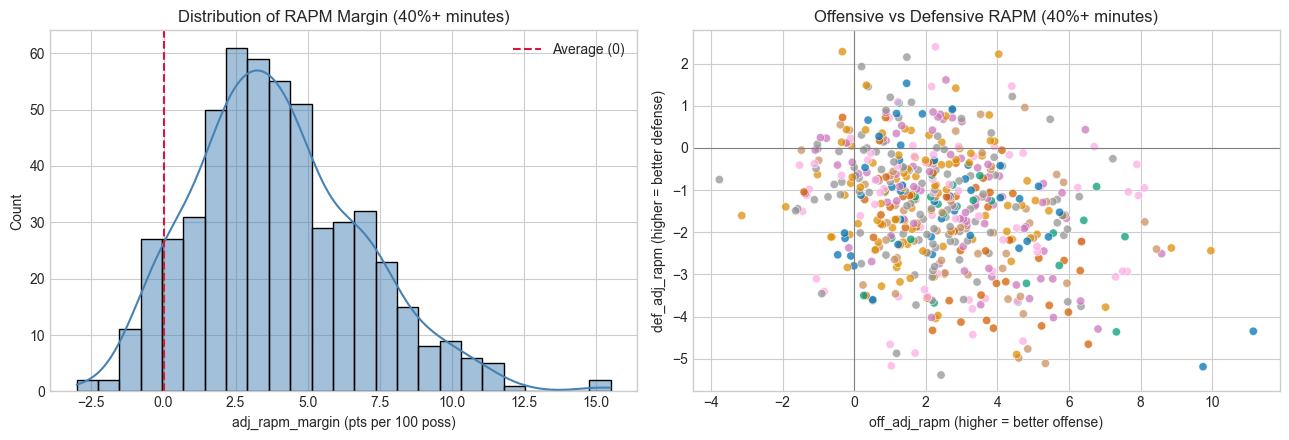

In [31]:
qualified = players[players['off_team_poss_pct'] >= 0.40].copy()
print(f'Players with >=40% of team offensive possessions: {len(qualified)} / {len(players)}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(qualified['adj_rapm_margin'], bins=25, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='crimson', ls='--', lw=1.5, label='Average (0)')
axes[0].set_title('Distribution of RAPM Margin (40%+ minutes)')
axes[0].set_xlabel('adj_rapm_margin (pts per 100 poss)')
axes[0].legend()

sns.scatterplot(
    data=qualified,
    x='off_adj_rapm', y='def_adj_rapm',
    hue='posClass', alpha=0.75, ax=axes[1], legend=False,
)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axvline(0, color='gray', lw=0.8)
axes[1].set_title('Offensive vs Defensive RAPM (40%+ minutes)')
axes[1].set_xlabel('off_adj_rapm (higher = better offense)')
axes[1].set_ylabel('def_adj_rapm (higher = better defense)')

plt.tight_layout()
plt.show()

In [32]:
top_rapm = (
    qualified
    .nlargest(15, 'adj_rapm_margin')[
        ['player_name', 'team', 'posClass', 'roster.year_class',
         'off_team_poss_pct', 'adj_rtg_margin', 'adj_rapm_margin',
         'off_adj_rapm', 'def_adj_rapm', 'transfer_dest']
    ]
    .reset_index(drop=True)
)
top_rapm

,player_name,team,posClass,roster.year_class,off_team_poss_pct,adj_rtg_margin,adj_rapm_margin,off_adj_rapm,def_adj_rapm,transfer_dest
0,"Boozer, Cameron",Duke,S-PF,Fr,0.837,15.487,15.495,11.146,-4.349,NBA
1,"Lendeborg, Yaxel",Michigan,S-PF,Sr,0.750,13.230,14.932,9.742,-5.190,
2,"Wagler, Keaton",Illinois,CG,Fr,0.834,11.543,12.398,9.960,-2.438,NBA
3,"Fears Jr., Jeremy",Michigan St.,PG,Jr,0.817,11.466,11.685,7.322,-4.364,NBA
4,"Thornton, Bruce",Ohio St.,CG,Sr,0.904,11.622,11.228,8.856,-2.372,
5,"Veesaar, Henri",North Carolina,PF/C,Jr,0.738,8.767,11.194,6.538,-4.656,NBA
6,"Momcilovic, Milan",Iowa St.,WF,Jr,0.752,11.573,11.106,6.810,-4.296,NBA
7,"Dybantsa, AJ",BYU,WF,Fr,0.865,11.784,11.095,8.586,-2.509,NBA
8,"Cluff, Oscar",Purdue,C,Sr,0.610,11.747,10.844,8.443,-2.400,
9,"Loyer, Fletcher",Purdue,CG,Sr,0.740,8.683,10.799,7.022,-3.777,


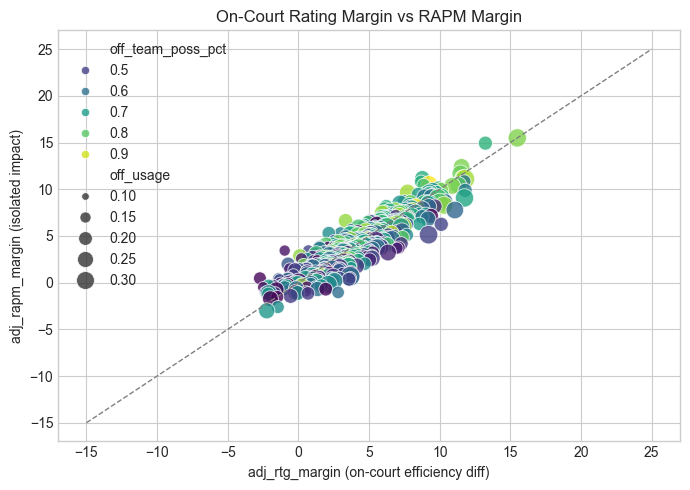

In [33]:
# Do high box-score margins always mean high RAPM?
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=qualified,
    x='adj_rtg_margin', y='adj_rapm_margin',
    hue='off_team_poss_pct', palette='viridis', size='off_usage',
    sizes=(30, 200), alpha=0.8, ax=ax,
)
ax.plot([-15, 25], [-15, 25], ls='--', color='gray', lw=1)
ax.set_title('On-Court Rating Margin vs RAPM Margin')
ax.set_xlabel('adj_rtg_margin (on-court efficiency diff)')
ax.set_ylabel('adj_rapm_margin (isolated impact)')
plt.tight_layout()
plt.show()

Points off the diagonal are instructive: a player can have strong on-court team efficiency (`adj_rtg_margin`) but modest RAPM if they share the floor with other elite players, or vice versa. For portal scouting, **RAPM is the better "translation" anchor**.

---
## 5. Usage, Minutes & Shot Profile

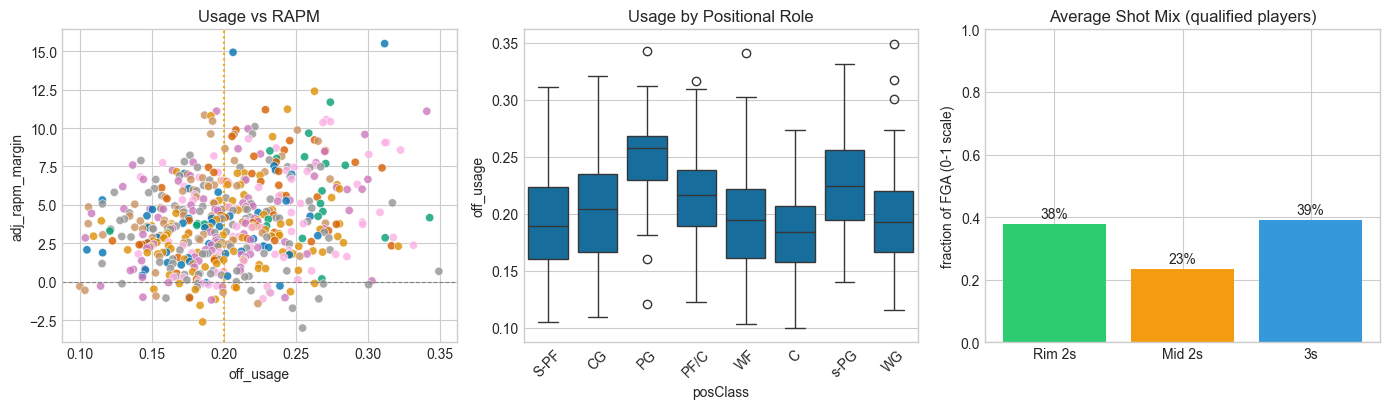

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

sns.scatterplot(
    data=qualified, x='off_usage', y='adj_rapm_margin',
    hue='posClass', alpha=0.8, ax=axes[0], legend=False,
)
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].axvline(0.20, color='orange', ls=':', label='~avg usage (0.20)')
axes[0].set_title('Usage vs RAPM')
axes[0].set_xlabel('off_usage')
axes[0].set_ylabel('adj_rapm_margin')

sns.boxplot(data=qualified, x='posClass', y='off_usage', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Usage by Positional Role')

shot_mix = qualified[['off_twoprimr', 'off_twopmidr', 'off_threepr']].mean()
shot_labels = ['Rim 2s', 'Mid 2s', '3s']
axes[2].bar(shot_labels, shot_mix.values, color=['#2ecc71', '#f39c12', '#3498db'])
axes[2].set_ylim(0, 1)
axes[2].set_title('Average Shot Mix (qualified players)')
axes[2].set_ylabel('fraction of FGA (0-1 scale)')
for i, v in enumerate(shot_mix.values):
    axes[2].text(i, v + 0.02, f'{v:.0%}', ha='center')

plt.tight_layout()
plt.show()

In [35]:
# Shooting efficiency by zone — helps evaluate fit (e.g., rim-only finisher vs spacer)
shooting_cols = ['off_threep', 'off_twop', 'off_twopmid', 'off_twoprim', 'off_ft']
shooting_labels = ['3P%', '2P%', 'Mid 2P%', 'Rim 2P%', 'FT%']
by_pos = qualified.groupby('posClass')[shooting_cols].mean()
by_pos.columns = shooting_labels
by_pos.sort_values('Rim 2P%', ascending=False)

,3P%,2P%,Mid 2P%,Rim 2P%,FT%
posClass,,,,,
C,0.116,0.626,0.507,0.672,0.618
PF/C,0.310,0.595,0.468,0.664,0.686
S-PF,0.329,0.566,0.436,0.634,0.742
WF,0.342,0.555,0.437,0.628,0.731
WG,0.330,0.514,0.411,0.584,0.748
s-PG,0.341,0.488,0.388,0.559,0.781
CG,0.351,0.476,0.375,0.558,0.789
PG,0.338,0.487,0.401,0.552,0.770


---
## 6. Transfer Portal Signals in This Export

In [36]:
portal = players[players['is_transfer_out']].copy()
print('Players with a transfer_dest value:', len(portal))
print('Breakdown:')
display(portal['transfer_dest'].value_counts().head(15).to_frame('count'))

portal_class = portal.groupby('roster.year_class').agg(
    players=('player_name', 'count'),
    median_rapm=('adj_rapm_margin', 'median'),
    median_mins=('off_team_poss_pct', 'median'),
).sort_values('players', ascending=False)
portal_class

Players with a transfer_dest value: 249
Breakdown:


,count
transfer_dest,
NBA,48
Vanderbilt,5
George Washington,5
BYU,4
Texas,4
West Virginia,4
UCLA,4
Oklahoma St.,4
Oregon,4


,players,median_rapm,median_mins
roster.year_class,,,
Jr,89,2.570,0.548
So,82,2.447,0.557
Fr,72,2.503,0.545
Sr,6,3.608,0.553


In [37]:
# Portal players with prediction fields (balanced high-major projection)
pred_cols = ['adj_rapm_margin_pred', 'off_adj_rapm_pred', 'def_adj_rapm_pred', 'off_rtg_pred', 'off_usage_pred']
portal_pred = portal.dropna(subset=['adj_rapm_margin_pred'], how='all').copy()
print('Portal players with at least one _pred field:', len(portal_pred))

if len(portal_pred) > 0:
    portal_pred['rapm_delta_pred'] = portal_pred['adj_rapm_margin_pred'] - portal_pred['adj_rapm_margin']
    display(
        portal_pred.nlargest(12, 'adj_rapm_margin_pred')[
            ['player_name', 'team', 'transfer_dest', 'posClass',
             'adj_rapm_margin', 'adj_rapm_margin_pred', 'rapm_delta_pred'] + pred_cols[1:]
        ]
    )
else:
    print('No _pred values in this export slice — re-export from Hoop Explorer transfer leaderboard for projections.')

Portal players with at least one _pred field: 249


,player_name,team,transfer_dest,posClass,adj_rapm_margin,adj_rapm_margin_pred,rapm_delta_pred,off_adj_rapm_pred,def_adj_rapm_pred,off_rtg_pred,off_usage_pred
0,"Boozer, Cameron",Duke,NBA,S-PF,15.495,0,-15.495,NaN,NaN,NaN,NaN
2,"Wagler, Keaton",Illinois,NBA,CG,12.398,0,-12.398,NaN,NaN,NaN,NaN
3,"Fears Jr., Jeremy",Michigan St.,NBA,PG,11.685,0,-11.685,NaN,NaN,NaN,NaN
5,"Veesaar, Henri",North Carolina,NBA,PF/C,11.194,0,-11.194,NaN,NaN,NaN,NaN
6,"Momcilovic, Milan",Iowa St.,NBA,WF,11.106,0,-11.106,NaN,NaN,NaN,NaN
7,"Dybantsa, AJ",BYU,NBA,WF,11.095,0,-11.095,NaN,NaN,NaN,NaN
11,"Bidunga, Flory",Kansas,NBA,C,10.454,0,-10.454,NaN,NaN,NaN,NaN
12,"Flemings, Kingston",Houston,NBA,s-PG,10.422,0,-10.422,NaN,NaN,NaN,NaN
13,"Tanner, Tyler",Vanderbilt,NBA,s-PG,10.358,0,-10.358,NaN,NaN,NaN,NaN
14,"Burries, Brayden",Arizona,NBA,WG,10.092,0,-10.092,NaN,NaN,NaN,NaN


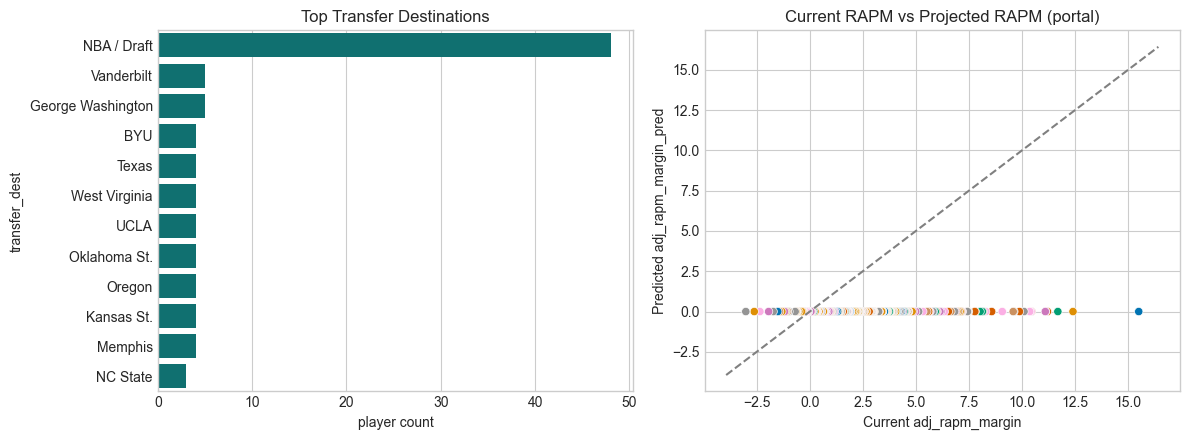

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

dest_counts = portal['transfer_dest'].replace({'NBA': 'NBA / Draft'}).value_counts().head(12)
sns.barplot(x=dest_counts.values, y=dest_counts.index, ax=axes[0], color='teal')
axes[0].set_title('Top Transfer Destinations')
axes[0].set_xlabel('player count')

if portal_pred['adj_rapm_margin_pred'].notna().any():
    sns.scatterplot(
        data=portal_pred.dropna(subset=['adj_rapm_margin_pred']),
        x='adj_rapm_margin', y='adj_rapm_margin_pred',
        hue='posClass', ax=axes[1], legend=False,
    )
    lims = axes[1].get_xlim()
    axes[1].plot(lims, lims, ls='--', color='gray')
    axes[1].set_title('Current RAPM vs Projected RAPM (portal)')
    axes[1].set_xlabel('Current adj_rapm_margin')
    axes[1].set_ylabel('Predicted adj_rapm_margin_pred')
else:
    sns.histplot(portal['adj_rapm_margin'], bins=20, ax=axes[1], color='coral')
    axes[1].set_title('RAPM Distribution — Portal Players')

plt.tight_layout()
plt.show()

---
## 7. Play Style Breakdown (Player Level)

Hoop Explorer tags how players generate offense (`off_style_*_pct` = plays per 100 player possessions). For portal fit, compare a recruit's style mix to the departing player or team archetype.

**Reading the chart:** Taller bars = more frequent play type for that player. Efficiency (`_ppp`) is not shown here — a player can run few post-ups but be elite on them.

In [39]:
def player_style_vector(row: pd.Series) -> pd.Series:
    return pd.Series({STYLE_LABELS[k]: row.get(f'off_style_{k}_pct', np.nan) for k in STYLE_BASES})


league_style = pd.DataFrame(
    {STYLE_LABELS[k]: players[f'off_style_{k}_pct'].mean() for k in STYLE_BASES},
    index=['league_avg'],
)
league_style.T.sort_values('league_avg', ascending=False).head(10)

,league_avg
Rim Attack,0.141
Perimeter Sniper,0.140
Transition,0.131
Attack & Kick,0.091
Scramble,0.083
Post-Up,0.071
Big Cut & Roll,0.054
PnR Passer,0.051
Mid-Range,0.047
Perimeter Cut,0.044


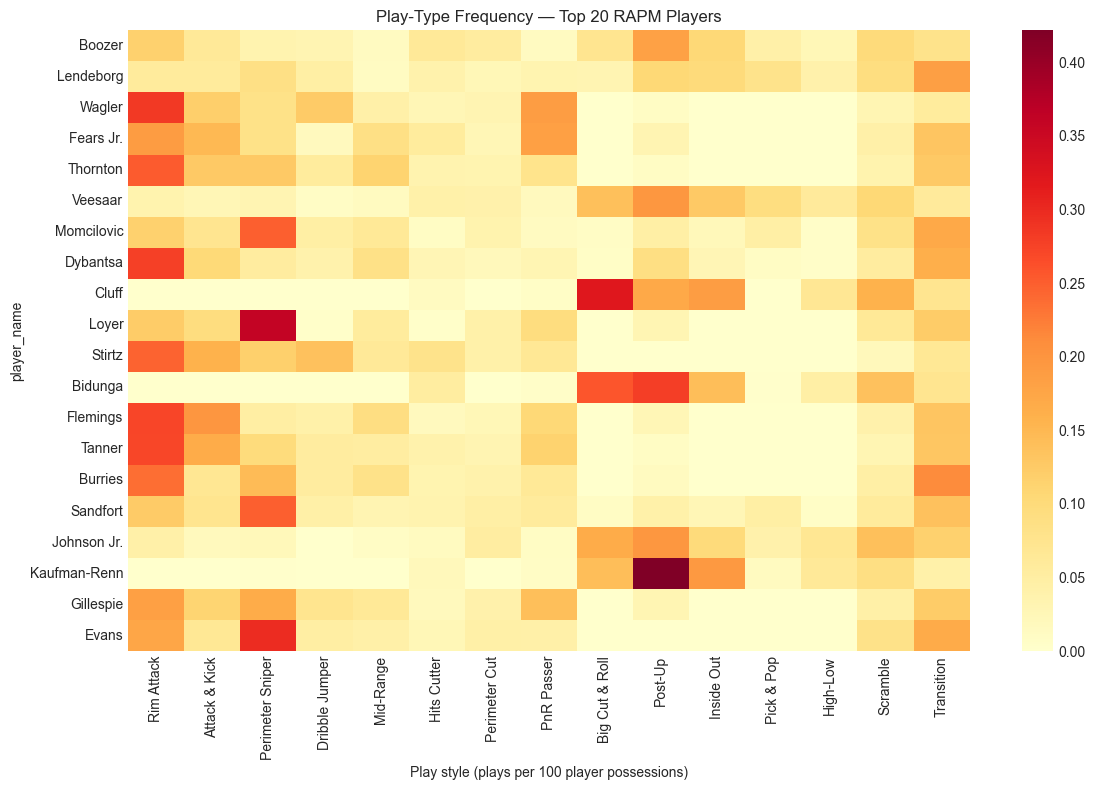

In [40]:
# Heatmap: top-20 RAPM players and their play-type frequencies
top_style = qualified.nlargest(20, 'adj_rapm_margin')
style_mat = top_style.apply(player_style_vector, axis=1)
style_mat.index = top_style['player_name'].str.split(',').str[0]  # surname only for labels

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(style_mat, cmap='YlOrRd', ax=ax)
ax.set_title('Play-Type Frequency — Top 20 RAPM Players')
ax.set_xlabel('Play style (plays per 100 player possessions)')
plt.tight_layout()
plt.show()

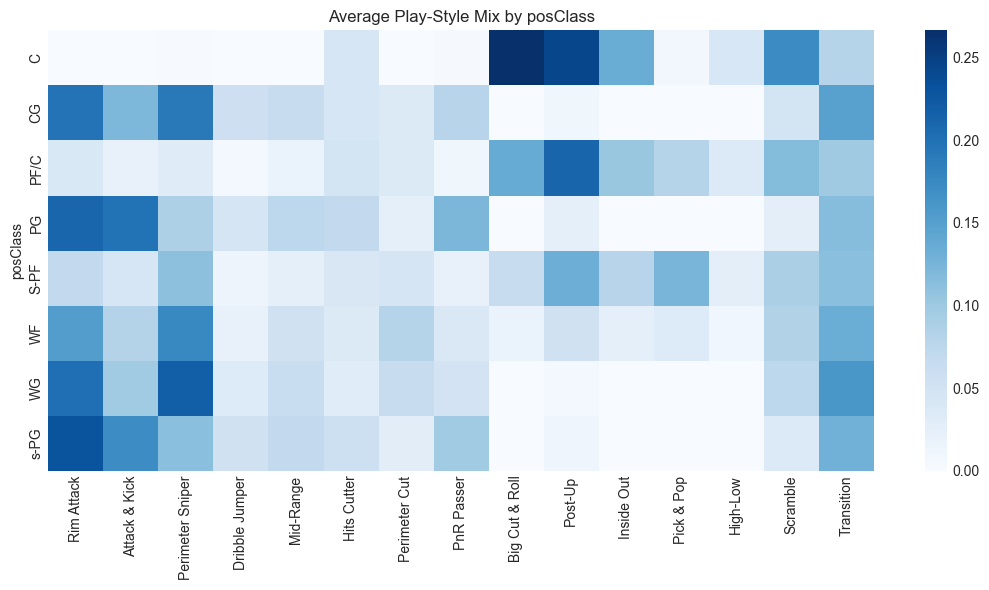

In [41]:
# Position-group style fingerprints
pos_style = qualified.groupby('posClass').apply(
    lambda g: pd.Series({STYLE_LABELS[k]: g[f'off_style_{k}_pct'].mean() for k in STYLE_BASES}),
    include_groups=False,
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pos_style, cmap='Blues', ax=ax)
ax.set_title('Average Play-Style Mix by posClass')
plt.tight_layout()
plt.show()

---
## 8. Team-Level Exploration (Power 6 Export)

Team columns mirror player concepts at squad level: adjusted efficiency (`adj_net`), four factors, transition/scramble splits, and offensive/defensive play-style frequencies.

In [42]:
team_cols_show = ['team_name', 'conf', 'record', 'adj_net', 'off_adj_ppp', 'def_adj_ppp', 'tempo', 'power']
teams.nlargest(15, 'adj_net')[team_cols_show]

,team_name,conf,record,adj_net,off_adj_ppp,def_adj_ppp,tempo,power
0,Michigan,Big Ten Conference,37-3,42.866,133.127,90.262,70.261,18.878
2,Duke,Atlantic Coast Conference,35-3,41.488,131.376,89.888,66.145,16.372
1,Arizona,Big 12 Conference,36-3,39.133,129.516,90.383,70.735,17.462
6,Illinois,Big Ten Conference,28-9,36.864,135.042,98.178,64.360,12.834
7,Florida,Southeastern Conference,27-8,36.085,128.658,92.573,71.186,12.378
5,Houston,Big 12 Conference,30-7,35.794,125.828,90.033,64.337,13.129
8,Iowa St.,Big 12 Conference,29-8,35.164,127.389,92.225,67.703,12.185
4,Purdue,Big Ten Conference,30-9,34.776,135.743,100.967,63.898,13.918
14,Gonzaga,West Coast Conference,31-4,33.083,123.763,90.680,69.523,10.143
3,UConn,Big East Conference,34-6,31.544,125.348,93.804,64.745,14.108


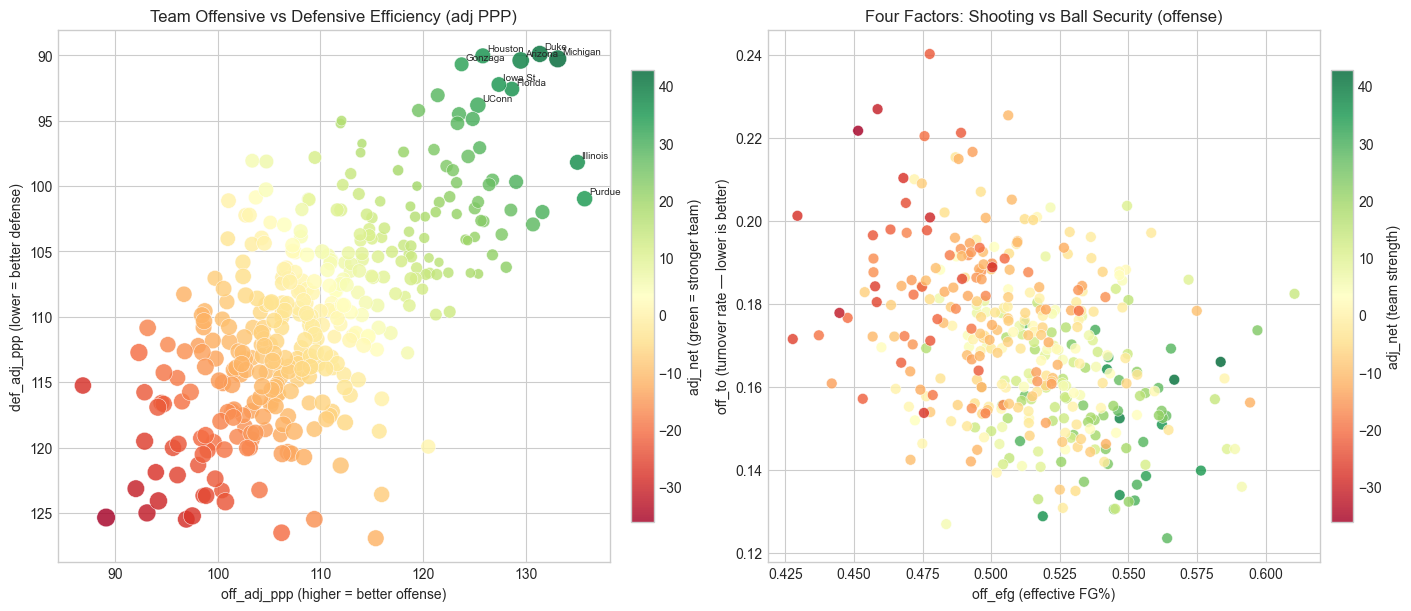

In [43]:
# Avoid hue='conf' — 31 conferences blow up the legend and squash the plots.
# Use adj_net color + colorbars; label only the top teams by net rating.
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
net_norm = plt.Normalize(teams['adj_net'].min(), teams['adj_net'].max())
power_sizes = np.clip(teams['power'].abs() * 6 + 50, 50, 200)

sc_eff = axes[0].scatter(
    teams['off_adj_ppp'],
    teams['def_adj_ppp'],
    c=teams['adj_net'],
    cmap='RdYlGn',
    norm=net_norm,
    s=power_sizes,
    alpha=0.82,
    edgecolors='white',
    linewidths=0.4,
)
axes[0].set_title('Team Offensive vs Defensive Efficiency (adj PPP)')
axes[0].set_xlabel('off_adj_ppp (higher = better offense)')
axes[0].set_ylabel('def_adj_ppp (lower = better defense)')
axes[0].invert_yaxis()
cbar0 = fig.colorbar(sc_eff, ax=axes[0], shrink=0.85, pad=0.02)
cbar0.set_label('adj_net (green = stronger team)')

for _, row in teams.nlargest(10, 'adj_net').iterrows():
    axes[0].annotate(
        row['team_name'],
        (row['off_adj_ppp'], row['def_adj_ppp']),
        fontsize=7,
        xytext=(3, 3),
        textcoords='offset points',
    )

sc_four = axes[1].scatter(
    teams['off_efg'],
    teams['off_to'],
    c=teams['adj_net'],
    cmap='RdYlGn',
    norm=net_norm,
    s=60,
    alpha=0.82,
    edgecolors='white',
    linewidths=0.4,
)
axes[1].set_title('Four Factors: Shooting vs Ball Security (offense)')
axes[1].set_xlabel('off_efg (effective FG%)')
axes[1].set_ylabel('off_to (turnover rate — lower is better)')
cbar1 = fig.colorbar(sc_four, ax=axes[1], shrink=0.85, pad=0.02)
cbar1.set_label('adj_net (team strength)')

plt.show()

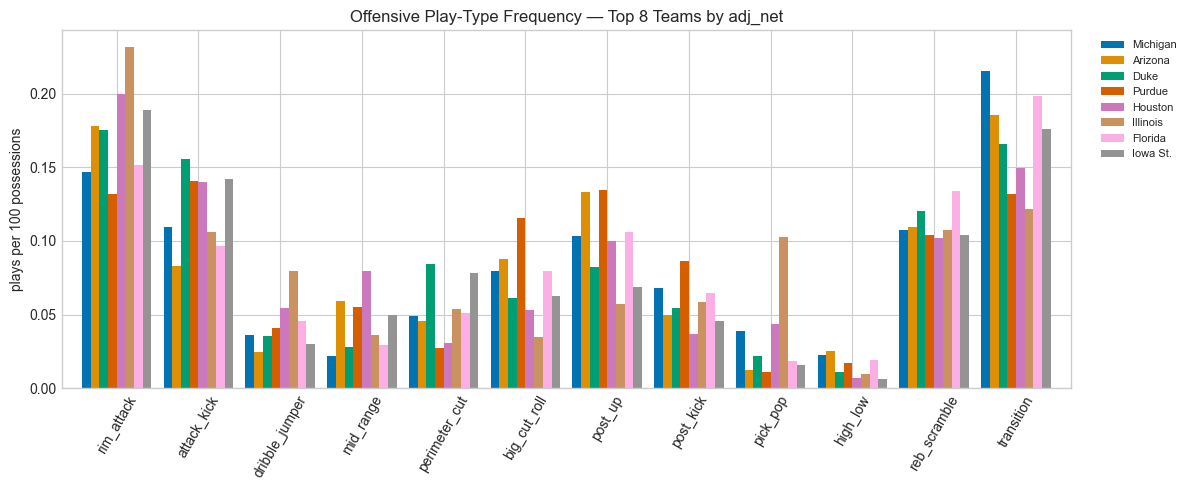

In [44]:
# Team play-style radar-style bar comparison for selected contenders
sample_teams = teams.nlargest(8, 'adj_net')['team_name'].tolist()
team_style_cols = [f'off_style_{k}_pct' for k in STYLE_BASES if f'off_style_{k}_pct' in teams.columns]
team_styles = teams[teams['team_name'].isin(sample_teams)].set_index('team_name')[team_style_cols]
team_styles.columns = [c.replace('off_style_', '').replace('_pct', '') for c in team_styles.columns]

fig, ax = plt.subplots(figsize=(12, 5))
team_styles.T.plot(kind='bar', ax=ax, width=0.85)
ax.set_title('Offensive Play-Type Frequency — Top 8 Teams by adj_net')
ax.set_ylabel('plays per 100 possessions')
ax.tick_params(axis='x', rotation=60)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## 9. Joining Player & Team Context (Portal Fit Sketch)

A simple merge on `team` + `year` lets us compare a player's impact to their team's overall strength — useful when asking whether a portal target elevated a good team or carried a weaker one.

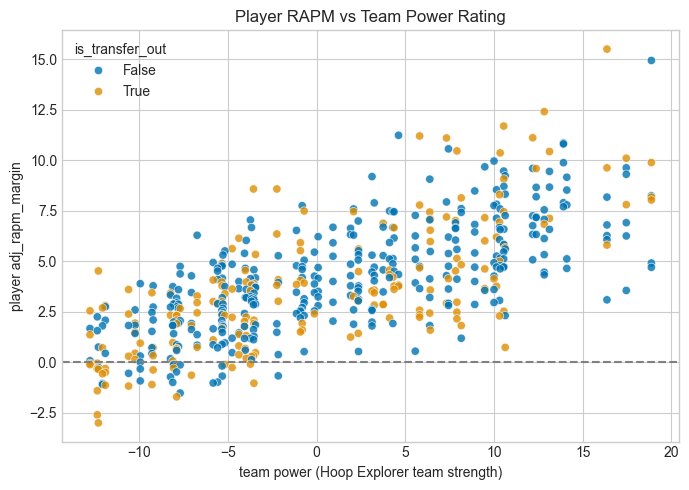

In [45]:
team_context = teams[['team_name', 'year', 'adj_net', 'off_adj_ppp', 'def_adj_ppp', 'tempo', 'power']].rename(
    columns={'team_name': 'team'}
)
merged = players.merge(team_context, on=['team', 'year'], how='left')

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=merged[merged['off_team_poss_pct'] >= 0.40],
    x='power', y='adj_rapm_margin',
    hue='is_transfer_out', alpha=0.8, ax=ax,
)
ax.axhline(0, color='gray', ls='--')
ax.set_title('Player RAPM vs Team Power Rating')
ax.set_xlabel('team power (Hoop Explorer team strength)')
ax.set_ylabel('player adj_rapm_margin')
plt.tight_layout()
plt.show()

In [46]:
# Players outperforming their team net rating — potential "carry" candidates
merged['rapm_vs_team'] = merged['adj_rapm_margin'] - merged['adj_net'] / 10  # rough scale alignment for exploration
standouts = (
    merged[merged['off_team_poss_pct'] >= 0.45]
    .nlargest(12, 'adj_rapm_margin')[
        ['player_name', 'team', 'adj_net', 'adj_rapm_margin', 'off_usage', 'transfer_dest', 'posClass']
    ]
)
standouts

,player_name,team,adj_net,adj_rapm_margin,off_usage,transfer_dest,posClass
0,"Boozer, Cameron",Duke,41.488,15.495,0.312,NBA,S-PF
1,"Lendeborg, Yaxel",Michigan,42.866,14.932,0.206,,S-PF
2,"Wagler, Keaton",Illinois,36.864,12.398,0.263,NBA,CG
3,"Fears Jr., Jeremy",Michigan St.,29.980,11.685,0.274,NBA,PG
4,"Thornton, Bruce",Ohio St.,23.223,11.228,0.244,,CG
5,"Veesaar, Henri",North Carolina,24.138,11.194,0.229,NBA,PF/C
6,"Momcilovic, Milan",Iowa St.,35.164,11.106,0.195,NBA,WF
7,"Dybantsa, AJ",BYU,26.729,11.095,0.341,NBA,WF
8,"Cluff, Oscar",Purdue,34.776,10.844,0.186,,C
9,"Loyer, Fletcher",Purdue,34.776,10.799,0.191,,CG


---
## 10. Key Takeaways for PortalPoint

1. **RAPM (`adj_rapm_margin`) should be a primary portal ranking pillar** — it is the best available open proxy for translation risk in this dataset.
2. **Always gate on minutes (`off_team_poss_pct`)** — the export includes high-profile low-minute players; require a threshold (e.g. 40%+) for serious scouting views.
3. **Play-style vectors (`off_style_*`) enable scheme-fit scoring** — pair with team clustering (see `team_clustering.ipynb`) to answer "does this transfer fit how we play?"
4. **Transfer metadata is partially populated** — `transfer_src`/`transfer_dest` are useful but incomplete; complement with Barttorvik transfer history for longitudinal tracking.
5. **`_pred` columns are high-value when present** — re-export from Hoop Explorer's transfer leaderboard to populate projections for incoming portal evaluations.
6. **Team export supports destination scouting** — `adj_net`, tempo, and style frequencies help staff evaluate whether a player's skills match a target program.

### Suggested next steps
- Feature engineering: normalize style vectors, store RAPM + usage + posClass in `data/features/`.
- Cross-source join: link `player_code` / `roster.ncaa_id` to Barttorvik player IDs where possible.
- Build portal UI views: *Impact*, *Usage*, *Style fit*, *Projection* tabs per player.